# Cross-Validation with Missing Events: Visual Demonstration

This notebook demonstrates how the two zero-event strategies handle missing stimulus events.

**Setup:**
- 1 voxel (for clarity)
- 2 runs, 300 TRs each, TR=1s
- 4 events, each occurs 2x per run (well-separated)
- Events are 1s duration, convolved with canonical HRF
- Uses actual fastfuncstuff CV code

**Key Comparison:**
- **"zero" strategy**: Uses zero beta for missing events → can't predict that variance
- **"nuisance" strategy**: Projects out unpredictable events from test → predicts what it can

**Scenarios:**
1. Baseline: All events present
2. Train missing Event 2: Can't learn β₂
3. Test missing Event 2: Learn β₂ but Event 2 not in test
4. Both missing different: Event 1 missing from test, Event 2 from train
5. Crowded events: Scenario 2 again, but with the events overlapping

**Which direction actually matters.** "Missing from *train*" is the case with
teeth: the event happens in the held-out run, but no beta was learned for it, so
under `"zero"` its BOLD is charged to the residual. "Missing from *test*" costs
nothing either way -- that column is zero across the held-out run, so it never
enters the prediction under either strategy. Scenarios 2 and 3 below show
exactly this, and the original text here had the two the wrong way round.

**Separation is the hidden variable.** Scenarios 1-4 use well-separated events,
which makes the stimulus columns near-orthogonal -- and under orthogonality
there is nothing shared for a strategy to mishandle. Three real bugs in the
`"nuisance"` path survived this notebook for exactly that reason. Scenario 5
varies the axis the others hold fixed.

In [12]:
import sys

sys.path.insert(0, '..')


import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import gamma

# Import actual CV code
from fastfuncstuff.glm.xval import compute_xval_r2

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Loaded fastfuncstuff CV code successfully!")

Loaded fastfuncstuff CV code successfully!


## Helper Functions for Data Generation

In [13]:
def canonical_hrf(tr: float = 1.0, duration: float = 32.0) -> np.ndarray:
    """Create canonical HRF (SPM-style double gamma)."""
    t = np.arange(0, duration, tr)
    
    # Positive gamma
    peak1, scale1 = 6.0, 1.0
    pos = gamma.pdf(t, peak1, scale=scale1)
    
    # Negative gamma (undershoot)
    peak2, scale2 = 16.0, 1.0
    neg = gamma.pdf(t, peak2, scale=scale2)
    
    # Combine
    hrf = pos - neg / 6.0
    hrf = hrf / hrf.max()  # Normalize
    
    return hrf


def create_event_design(
    n_timepoints: int,
    event_onsets: list[int],
    tr: float = 1.0,
    duration: float = 1.0,
) -> np.ndarray:
    """Create HRF-convolved design for a single event type."""
    # Stick function
    stick = np.zeros(n_timepoints)
    for onset in event_onsets:
        if 0 <= onset < n_timepoints:
            stick[onset] = duration / tr
    
    # Convolve with HRF
    hrf = canonical_hrf(tr=tr, duration=32.0)
    convolved = np.convolve(stick, hrf, mode='full')[:n_timepoints]
    
    return convolved


def create_full_design(
    n_timepoints: int,
    n_events: int,
    events_per_run: int = 2,
    missing_events: list[int] = None,
    seed: int = 42,
    crowd: float = 1.0,
) -> tuple[np.ndarray, list[list[int]]]:
    """
    Create design matrix with well-separated events.

    crowd < 1 shrinks the spacing between event bins so their HRF responses
    overlap. At crowd=1 (the original setting) the stimulus columns are close
    to orthogonal, which is the regime where every strategy agrees -- see
    Scenario 5 for why that matters.
    
    Returns
    -------
    design : np.ndarray
        Design matrix (n_timepoints, n_events)
    onset_times : List[List[int]]
        Onset times for each event
    """
    if missing_events is None:
        missing_events = []
    
    rng = np.random.RandomState(seed)
    design = np.zeros((n_timepoints, n_events))
    onset_times = []
    
    # Total events across all types
    total_events = n_events * events_per_run
    
    # Create well-separated time bins
    # Leave buffer at start (30 TRs) and end (30 TRs)
    usable_time = n_timepoints - 60
    bin_size = max(1, int((usable_time // total_events) * crowd))
    
    # Assign bins to events
    all_bins = list(range(total_events))
    rng.shuffle(all_bins)
    
    bin_idx = 0
    for event_idx in range(n_events):
        if event_idx in missing_events:
            onset_times.append([])
        else:
            onsets = []
            for _ in range(events_per_run):
                # Get bin
                bin_num = all_bins[bin_idx]
                bin_idx += 1
                
                # Random position within bin
                bin_start = 30 + bin_num * bin_size
                onset = bin_start + rng.randint(0, max(1, bin_size - 10))
                onsets.append(onset)
            
            onset_times.append(sorted(onsets))
            design[:, event_idx] = create_event_design(n_timepoints, onsets)
    
    return design, onset_times


def generate_fmri_data(
    design: np.ndarray,
    true_betas: np.ndarray,
    noise_std: float = 0.5,
    seed: int = 42,
) -> np.ndarray:
    """Generate synthetic fMRI data."""
    rng = np.random.RandomState(seed)
    signal = design @ true_betas
    noise = rng.randn(len(signal)) * noise_std
    return signal + noise


print("Helper functions defined!")

Helper functions defined!


## Setup: Common Parameters

In [14]:
# Parameters
n_timepoints = 300  # TRs per run (5 minutes)
n_events = 4  # Event types
events_per_run = 2  # Each event occurs 2x per run
tr = 1.0  # seconds
noise_std = 0.5  # Noise level

# True betas (same for both runs!)
true_betas = np.array([2.0, 1.5, 1.0, 0.5])  # Event 0 strongest, Event 3 weakest

# Colors and names
event_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
event_names = ['Event 0', 'Event 1', 'Event 2', 'Event 3']

print(f"True betas: {true_betas}")
print(f"Events per run: {events_per_run}")
print(f"Total TRs per run: {n_timepoints}")
print(f"Total duration: {n_timepoints * tr / 60:.1f} minutes per run")

True betas: [2.  1.5 1.  0.5]
Events per run: 2
Total TRs per run: 300
Total duration: 5.0 minutes per run


## Helper: Run CV with Both Strategies

In [15]:
def run_cv_scenario(
    train_missing: list[int],
    test_missing: list[int],
    verbose: bool = True,
    crowd: float = 1.0,
) -> tuple[dict, dict, dict]:
    """
    Run CV with both strategies for a given missing event scenario.
    
    Returns
    -------
    data_dict : dict
        Contains train/test data and designs
    results_zero : dict
        Results from "zero" strategy
    results_nuisance : dict
        Results from "nuisance" strategy
    """
    # Create designs
    design_train, onsets_train = create_full_design(
        n_timepoints, n_events, events_per_run, train_missing, seed=42, crowd=crowd
    )
    design_test, onsets_test = create_full_design(
        n_timepoints, n_events, events_per_run, test_missing, seed=43, crowd=crowd
    )
    
    # Generate data
    data_train = generate_fmri_data(design_train, true_betas, noise_std, seed=100)
    data_test = generate_fmri_data(design_test, true_betas, noise_std, seed=101)
    
    # Package data (1 voxel, n_timepoints)
    data_train_2d = data_train.reshape(1, -1)
    data_test_2d = data_test.reshape(1, -1)
    data_concat = np.concatenate([data_train_2d, data_test_2d], axis=1)
    
    # Full design matrix (train + test)
    design_full = np.vstack([design_train, design_test])
    
    # Convert to torch
    data_torch = torch.from_numpy(data_concat).float()
    design_torch = torch.from_numpy(design_full).float()
    
    # Run info
    run_starts = [0, n_timepoints]
    stim_indices = list(range(n_events))
    nuisance_indices = []  # No nuisance for simplicity
    
    # CV splits: train on run 0, test on run 1
    cv_splits = [([0], [1])]
    
    # Run with "zero" strategy
    results_zero = compute_xval_r2(
        data=data_torch,
        design_matrix=design_torch,
        run_starts=run_starts,
        stim_indices=stim_indices,
        nuisance_indices=nuisance_indices,
        cv_splits=cv_splits,
        metric='cod',
        zero_event_strategy='zero',
        device=torch.device('cpu'),
        verbose=False,
    )
    
    # Run with "nuisance" strategy
    results_nuisance = compute_xval_r2(
        data=data_torch,
        design_matrix=design_torch,
        run_starts=run_starts,
        stim_indices=stim_indices,
        nuisance_indices=nuisance_indices,
        cv_splits=cv_splits,
        metric='cod',
        zero_event_strategy='nuisance',
        device=torch.device('cpu'),
        verbose=False,
    )
    
    # Also fit betas manually for visualization
    train_present = ~np.all(design_train == 0, axis=0)
    design_train_fit = design_train[:, train_present]
    
    if design_train_fit.shape[1] > 0:
        betas_fit_vals = np.linalg.lstsq(design_train_fit, data_train, rcond=None)[0]
        betas_fit = np.zeros(n_events)
        betas_fit[train_present] = betas_fit_vals
    else:
        betas_fit = np.zeros(n_events)
    
    # Predictions
    pred_zero = design_test @ betas_fit
    
    # Traces for the plots below. Only TEST-ONLY events are projected: a
    # train-only column is identically zero across the test run, so including it
    # here would add zero columns to the basis and change nothing. Data and
    # prediction design get the SAME projection (Frisch-Waugh-Lovell) -- projecting
    # one side only puts their shared variance into the residual as fake error.
    test_present = ~np.all(design_test == 0, axis=0)
    predictable = train_present & test_present
    unpredictable = train_present & ~test_present  # in train, absent from test
    test_only = ~train_present & test_present      # in test, absent from train: unpredictable

    design_pred = design_test[:, predictable]
    if np.any(test_only):
        to_project = design_test[:, test_only]
        # Orthonormal basis, so the projection is exact rather than ridge-shrunk.
        basis = np.linalg.svd(to_project, full_matrices=False)[0]
        data_test_proj = data_test - basis @ (basis.T @ data_test)
        design_pred = design_pred - basis @ (basis.T @ design_pred)
    else:
        data_test_proj = data_test
    pred_nuisance = design_pred @ betas_fit[predictable]

    # The reported R2 comes from the LIBRARY, not from the traces above. These
    # used to be hand-computed here, which meant the notebook validated a copy of
    # the logic rather than the shipped code -- and the two silently drifted apart.
    r2_zero = float(results_zero["r2"].item())
    r2_nuisance = float(results_nuisance["r2"].item())
    
    if verbose:
        print(f"Train missing: {train_missing}")
        print(f"Test missing:  {test_missing}")
        print(f"True betas:    {true_betas}")
        print(f"Fitted betas:  {betas_fit}")
        print("")
        print(f"R² (zero):     {r2_zero:.4f}")
        print(f"R² (nuisance): {r2_nuisance:.4f}")
        print(f"Improvement:   {r2_nuisance - r2_zero:.4f}")
    
    data_dict = {
        'data_train': data_train,
        'data_test': data_test,
        'data_test_proj': data_test_proj,
        'design_train': design_train,
        'design_test': design_test,
        'onsets_train': onsets_train,
        'onsets_test': onsets_test,
        'betas_fit': betas_fit,
        'pred_zero': pred_zero,
        'pred_nuisance': pred_nuisance,
        'r2_zero': r2_zero,
        'r2_nuisance': r2_nuisance,
    }
    
    return data_dict, results_zero, results_nuisance


print("CV runner defined!")

CV runner defined!


## Plotting Function

In [16]:
def plot_scenario(data_dict, title, train_missing, test_missing):
    """
    Plot train/test data and both prediction strategies.
    """
    fig, axes = plt.subplots(4, 1, figsize=(16, 14))
    time = np.arange(n_timepoints) * tr
    
    data_train = data_dict['data_train']
    data_test = data_dict['data_test']
    data_test_proj = data_dict['data_test_proj']
    design_train = data_dict['design_train']
    design_test = data_dict['design_test']
    onsets_train = data_dict['onsets_train']
    onsets_test = data_dict['onsets_test']
    betas_fit = data_dict['betas_fit']
    pred_zero = data_dict['pred_zero']
    pred_nuisance = data_dict['pred_nuisance']
    r2_zero = data_dict['r2_zero']
    r2_nuisance = data_dict['r2_nuisance']
    
    # Panel 1: Train data
    ax = axes[0]
    ax.plot(time, data_train, 'k-', linewidth=2, label='Train Data', alpha=0.7)
    ax.plot(time, design_train @ true_betas, 'k--', linewidth=1, label='True Signal', alpha=0.5)
    
    for event_idx in range(n_events):
        for onset in onsets_train[event_idx]:
            ax.axvline(onset * tr, color=event_colors[event_idx], alpha=0.4, linestyle='-', linewidth=2)
    
    if train_missing:
        missing_str = ', '.join([f'Event {i}' for i in train_missing])
        ax.text(0.02, 0.95, f'⚠️ MISSING: {missing_str}', transform=ax.transAxes,
                fontsize=12, fontweight='bold', color='red',
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Signal', fontsize=12)
    ax.set_title('Train Run: Fit betas on this data', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Test data
    ax = axes[1]
    ax.plot(time, data_test, 'k-', linewidth=2, label='Test Data', alpha=0.7)
    ax.plot(time, design_test @ true_betas, 'k--', linewidth=1, label='True Signal', alpha=0.5)
    
    for event_idx in range(n_events):
        for onset in onsets_test[event_idx]:
            ax.axvline(onset * tr, color=event_colors[event_idx], alpha=0.4, linestyle='-', linewidth=2)
    
    if test_missing:
        missing_str = ', '.join([f'Event {i}' for i in test_missing])
        ax.text(0.02, 0.95, f'⚠️ MISSING: {missing_str}', transform=ax.transAxes,
                fontsize=12, fontweight='bold', color='red',
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Signal', fontsize=12)
    ax.set_title('Test Run: Predict this data', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Panel 3: "Zero" strategy prediction
    ax = axes[2]
    ax.plot(time, data_test, 'k-', linewidth=2, label='Test Data', alpha=0.5)
    ax.plot(time, pred_zero, 'r-', linewidth=2, label='Prediction (zero)', alpha=0.8)
    ax.plot(time, data_test - pred_zero, 'gray', linewidth=1, label='Residual', alpha=0.5)
    
    # Highlight missing events if they cause problems
    if train_missing:
        for event_idx in train_missing:
            for onset in onsets_test[event_idx]:
                ax.axvspan(onset*tr, (onset+15)*tr, color='red', alpha=0.1)
    
    ax.text(0.98, 0.95, f'Strategy: "zero"\nR² = {r2_zero:.4f}', 
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Signal', fontsize=12)
    ax.set_title('Strategy 1: "zero" - Use zero beta for missing events', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Panel 4: "Nuisance" strategy prediction
    ax = axes[3]
    
    # If we projected, show projected data
    if not np.allclose(data_test, data_test_proj):
        ax.plot(time, data_test, 'k-', linewidth=1, label='Test Data (original)', alpha=0.3)
        ax.plot(time, data_test_proj, 'k-', linewidth=2, label='Test Data (projected)', alpha=0.7)
        ax.plot(time, pred_nuisance, 'b-', linewidth=2, label='Prediction (nuisance)', alpha=0.8)
        ax.plot(time, data_test_proj - pred_nuisance, 'gray', linewidth=1, label='Residual', alpha=0.5)
    else:
        ax.plot(time, data_test, 'k-', linewidth=2, label='Test Data', alpha=0.5)
        ax.plot(time, pred_nuisance, 'b-', linewidth=2, label='Prediction (nuisance)', alpha=0.8)
        ax.plot(time, data_test - pred_nuisance, 'gray', linewidth=1, label='Residual', alpha=0.5)
    
    improvement = r2_nuisance - r2_zero
    color = 'lightgreen' if improvement > 0.01 else 'lightyellow'
    
    ax.text(0.98, 0.95, f'Strategy: "nuisance"\nR² = {r2_nuisance:.4f}\nΔR² = {improvement:+.4f}', 
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Signal', fontsize=12)
    ax.set_title('Strategy 2: "nuisance" - Project out unpredictable events, predict the rest', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Overall title and legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=event_colors[i], alpha=0.5, 
                             label=f'{event_names[i]} (β={true_betas[i]:.1f}, fit={betas_fit[i]:.2f})') 
                       for i in range(n_events)]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=10, 
               bbox_to_anchor=(0.5, 0.99))
    
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


print("Plotting function defined!")

Plotting function defined!


## Scenario 1: Baseline - All Events Present


SCENARIO 1: Baseline - All events present
Train missing: []
Test missing:  []
True betas:    [2.  1.5 1.  0.5]
Fitted betas:  [1.94790013 1.58863263 0.6555106  0.65550526]

R² (zero):     0.4153
R² (nuisance): 0.4153
Improvement:   0.0000


/home/logan/Dropbox/Resources/code/fastfuncstuff/notebooks/../fastfuncstuff/glm/xval.py:1765: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  "r2_std": r2_final.std(),


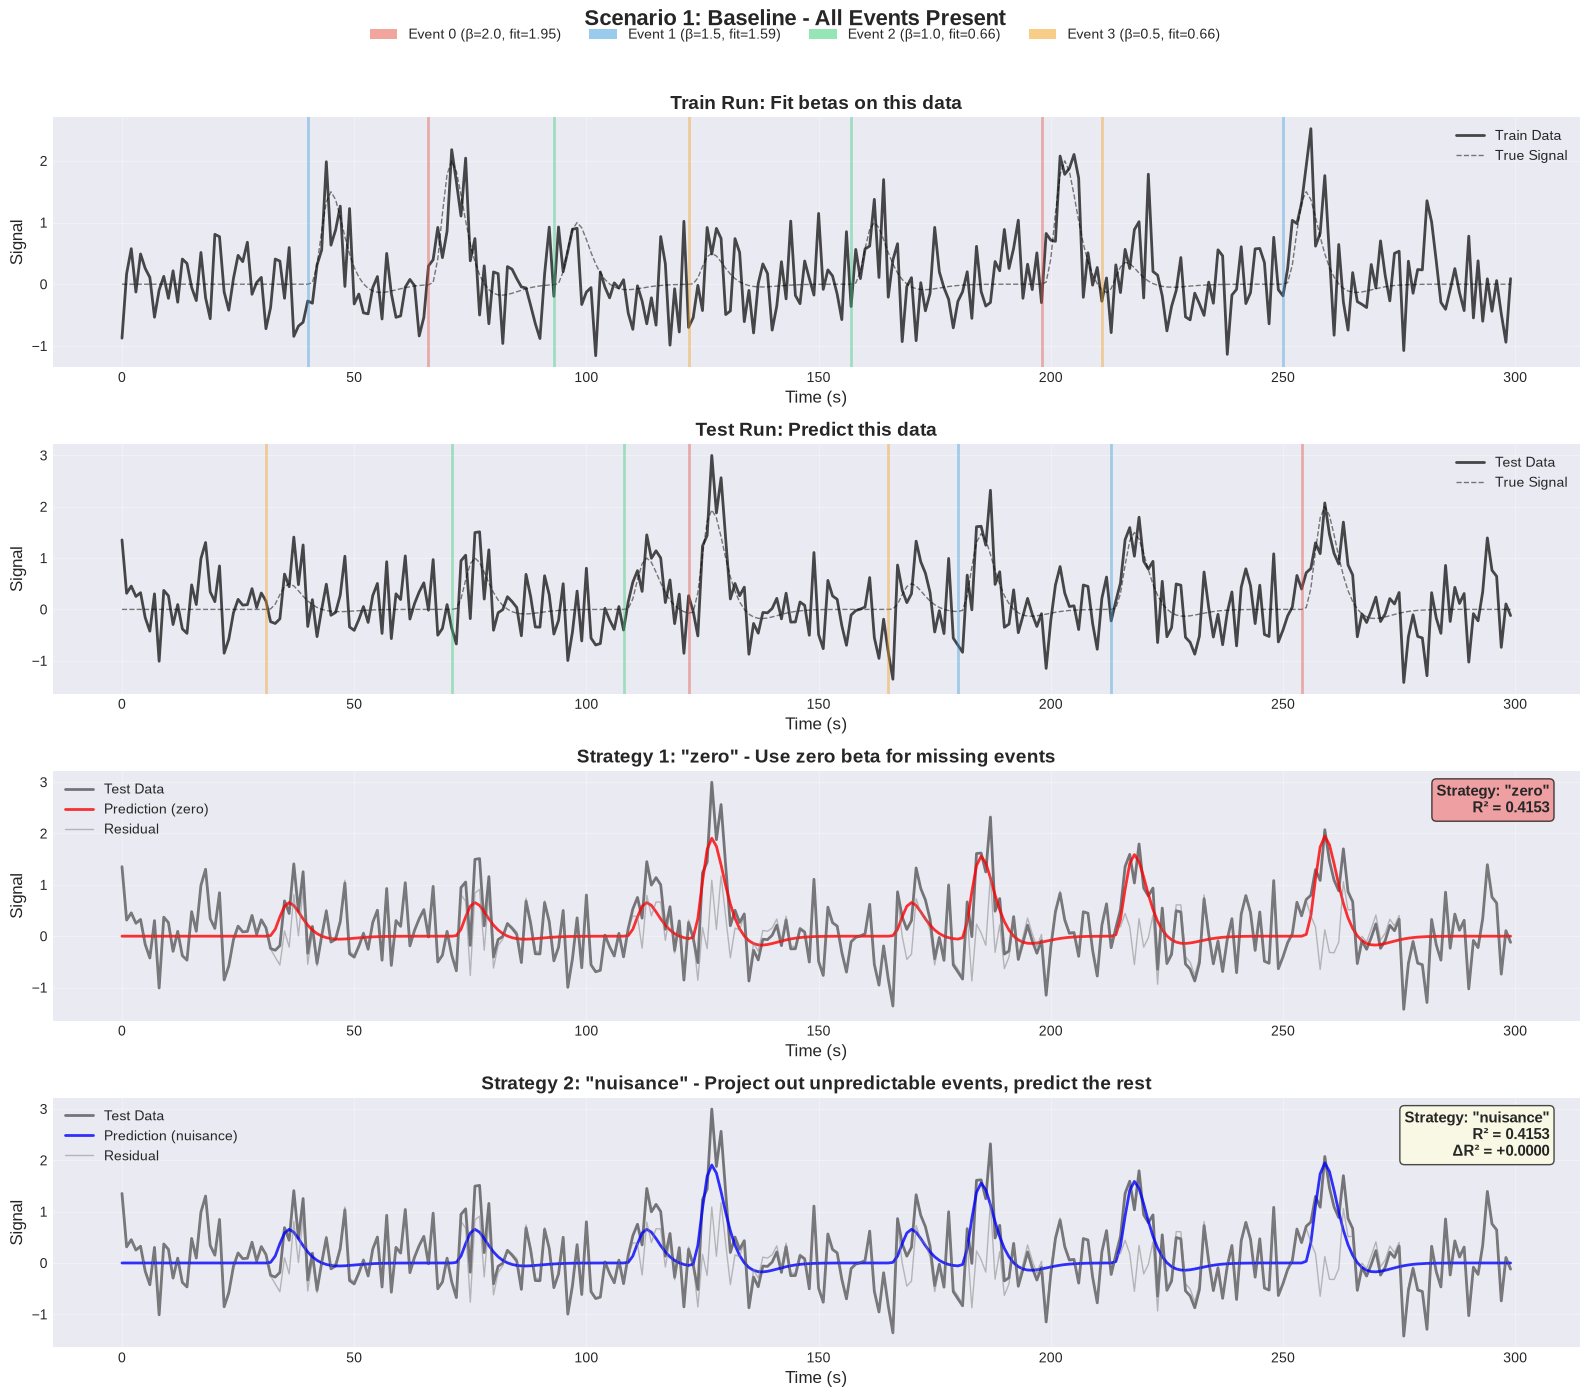

In [17]:
print("\n" + "="*70)
print("SCENARIO 1: Baseline - All events present")
print("="*70)

data_dict, res_zero, res_nuisance = run_cv_scenario(
    train_missing=[],
    test_missing=[],
    verbose=True,
)

plot_scenario(
    data_dict,
    'Scenario 1: Baseline - All Events Present',
    train_missing=[],
    test_missing=[],
)

## Scenario 2: Train Missing Event 2

**Key issue**: Can't learn β₂, so can't predict Event 2 signal in test.

**Expected**: `"nuisance"` wins. This is the case with teeth -- Event 2 happens in
the held-out run but no beta was learned for it, so `"zero"` charges its BOLD to
the residual while `"nuisance"` declines to score that subspace.


SCENARIO 2: Train missing Event 2
Train missing: [2]
Test missing:  []
True betas:    [2.  1.5 1.  0.5]
Fitted betas:  [1.94125022 1.58863015 0.         0.1555067 ]

R² (zero):     0.3372
R² (nuisance): 0.3828
Improvement:   0.0456


/tmp/ipykernel_2306656/89214026.py:125: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
/home/logan/miniconda3/envs/py314_ffs/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


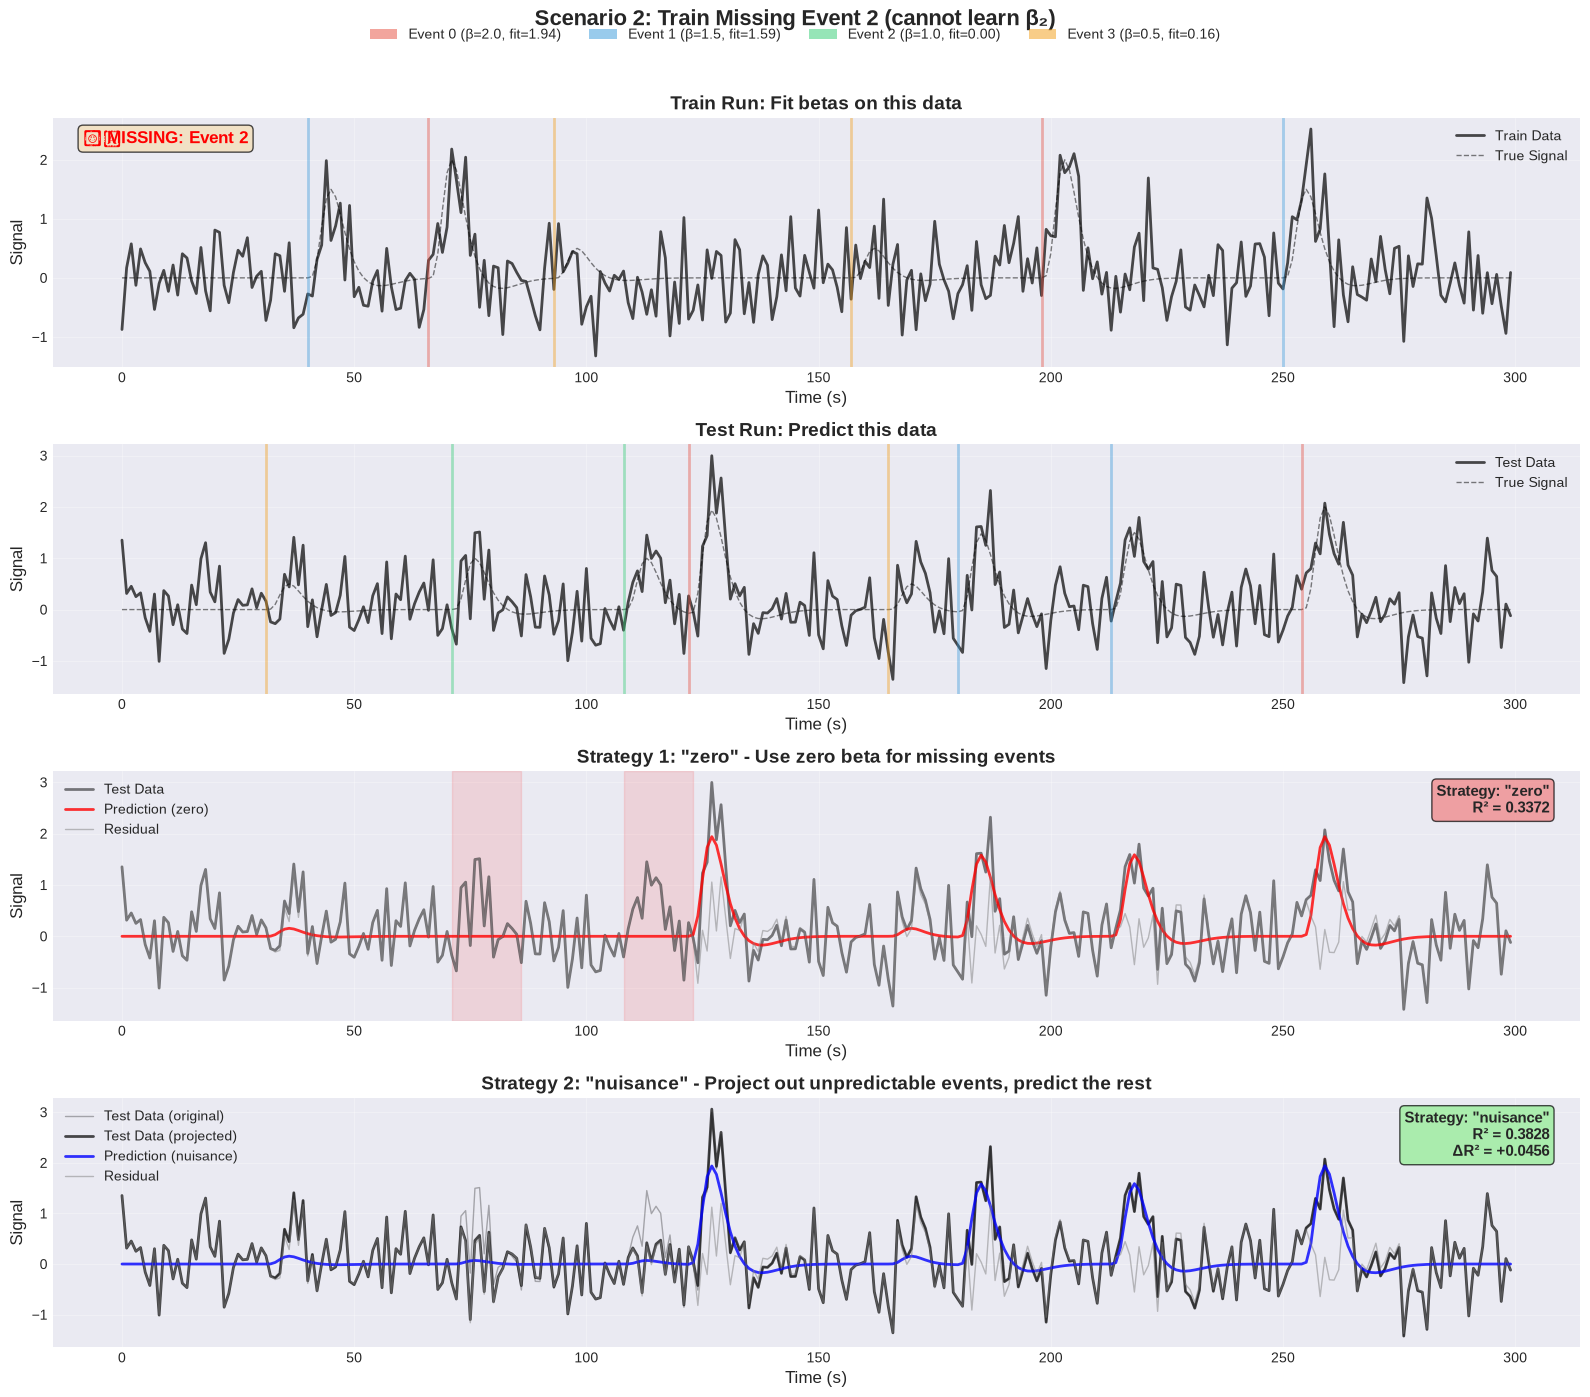

In [18]:
print("\n" + "="*70)
print("SCENARIO 2: Train missing Event 2")
print("="*70)

data_dict, res_zero, res_nuisance = run_cv_scenario(
    train_missing=[2],
    test_missing=[],
    verbose=True,
)

plot_scenario(
    data_dict,
    'Scenario 2: Train Missing Event 2 (cannot learn β₂)',
    train_missing=[2],
    test_missing=[],
)

## Scenario 3: Test Missing Event 2

**Key issue**: Learn β₂ from train, but Event 2 not in test data.

**Expected**: no difference at all. `"zero"` predicts through
`test_stim_design[:, test_present_mask]`, which already excludes a test-absent
column, so β₂ is never used -- the original expectation here was wrong. And the
projection `"nuisance"` would apply is a no-op, because that column is zero
across the whole test set. This case is why the projector basis is built from
the test-only columns alone.


SCENARIO 3: Test missing Event 2
Train missing: []
Test missing:  [2]
True betas:    [2.  1.5 1.  0.5]
Fitted betas:  [1.94790013 1.58863263 0.6555106  0.65550526]

R² (zero):     0.3935
R² (nuisance): 0.3935
Improvement:   0.0000


/tmp/ipykernel_2306656/89214026.py:125: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


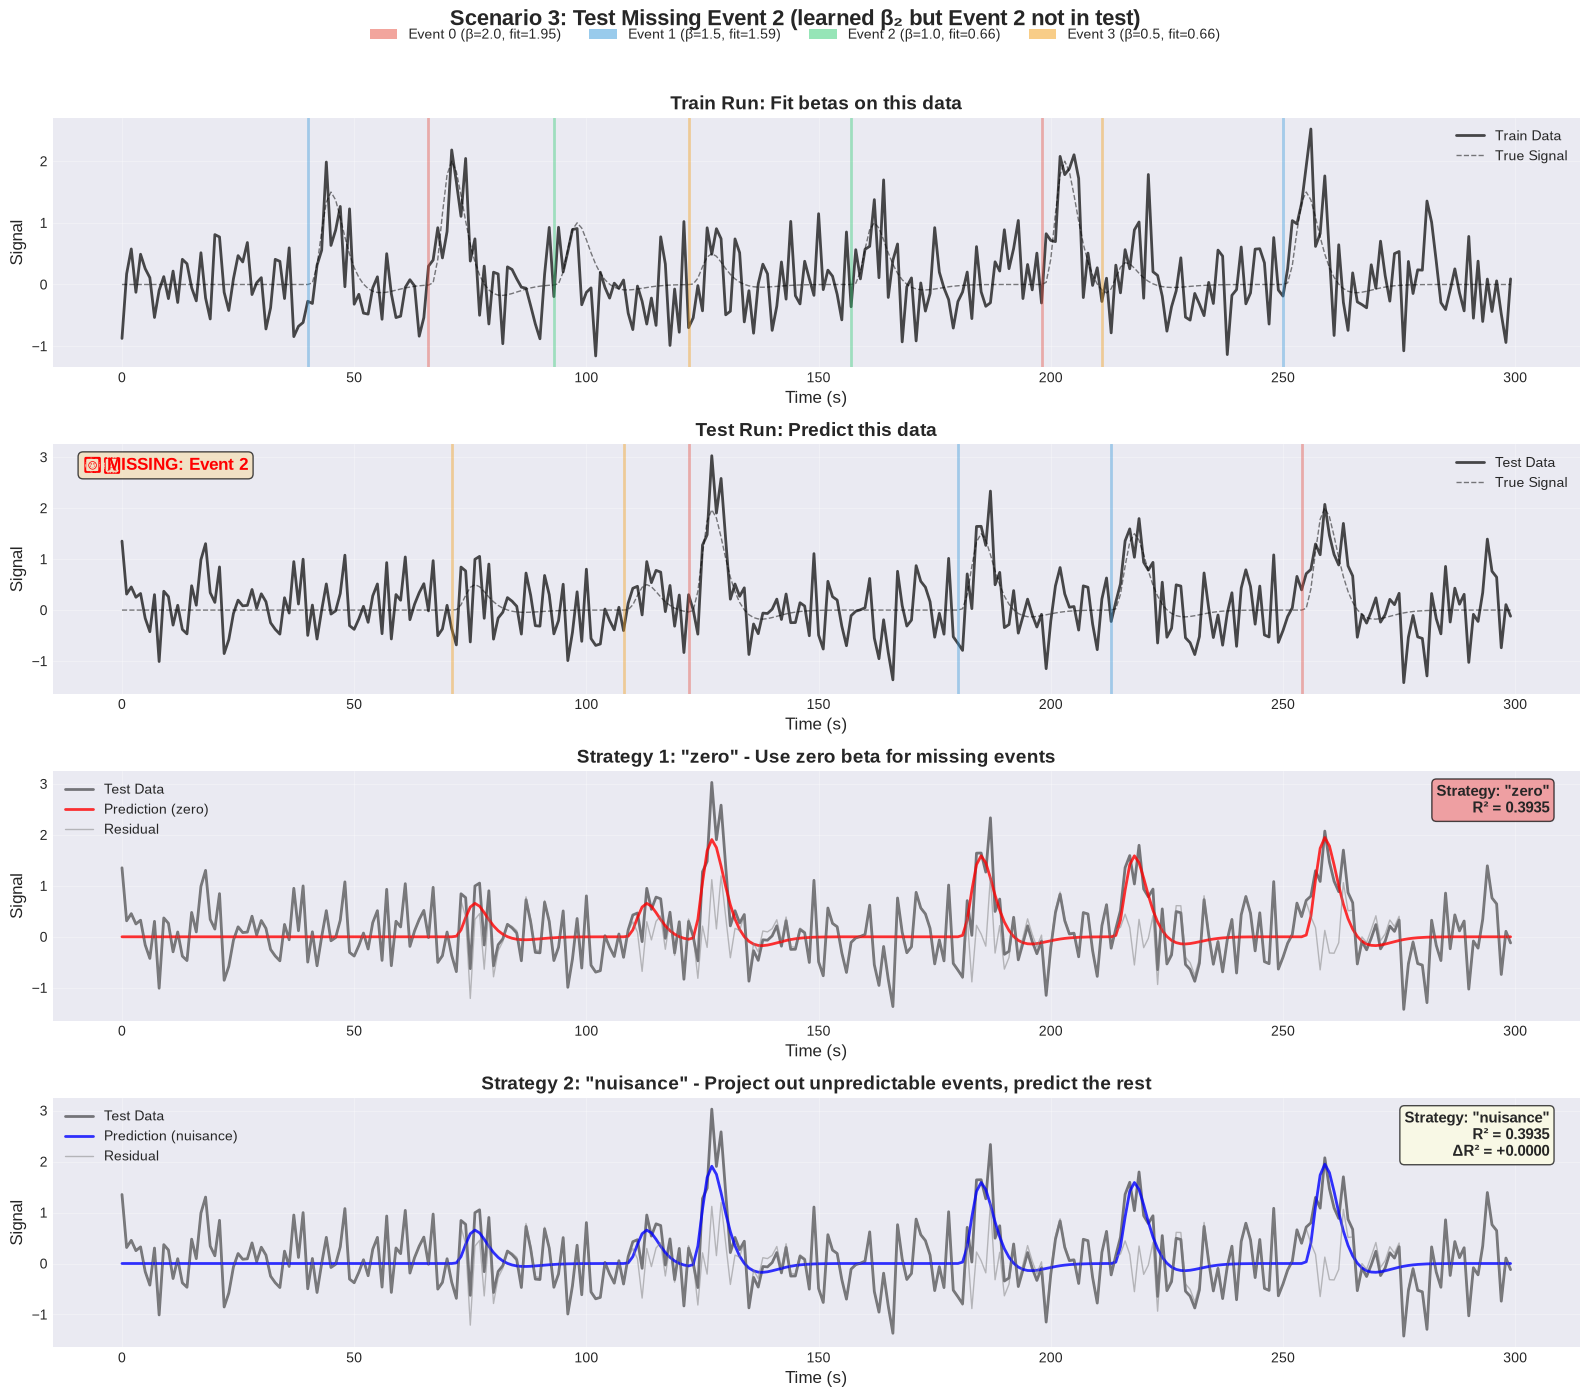

In [19]:
print("\n" + "="*70)
print("SCENARIO 3: Test missing Event 2")
print("="*70)

data_dict, res_zero, res_nuisance = run_cv_scenario(
    train_missing=[],
    test_missing=[2],
    verbose=True,
)

plot_scenario(
    data_dict,
    'Scenario 3: Test Missing Event 2 (learned β₂ but Event 2 not in test)',
    train_missing=[],
    test_missing=[2],
)

## Scenario 4: Both Missing Different Events

**Complex case**:
- Event 1 missing from test (learned β₁ but shouldn't use)
- Event 2 missing from train (can't learn β₂)

**Expected**: `"nuisance"` wins, but entirely on the Event 2 (train-missing)
half. The Event 1 half contributes nothing, for the reason Scenario 3 gives.


SCENARIO 4: Both missing different events
Train missing: [2]
Test missing:  [1]
True betas:    [2.  1.5 1.  0.5]
Fitted betas:  [1.94125022 1.58863015 0.         0.1555067 ]

R² (zero):     0.2521
R² (nuisance): 0.2904
Improvement:   0.0383


/tmp/ipykernel_2306656/89214026.py:125: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


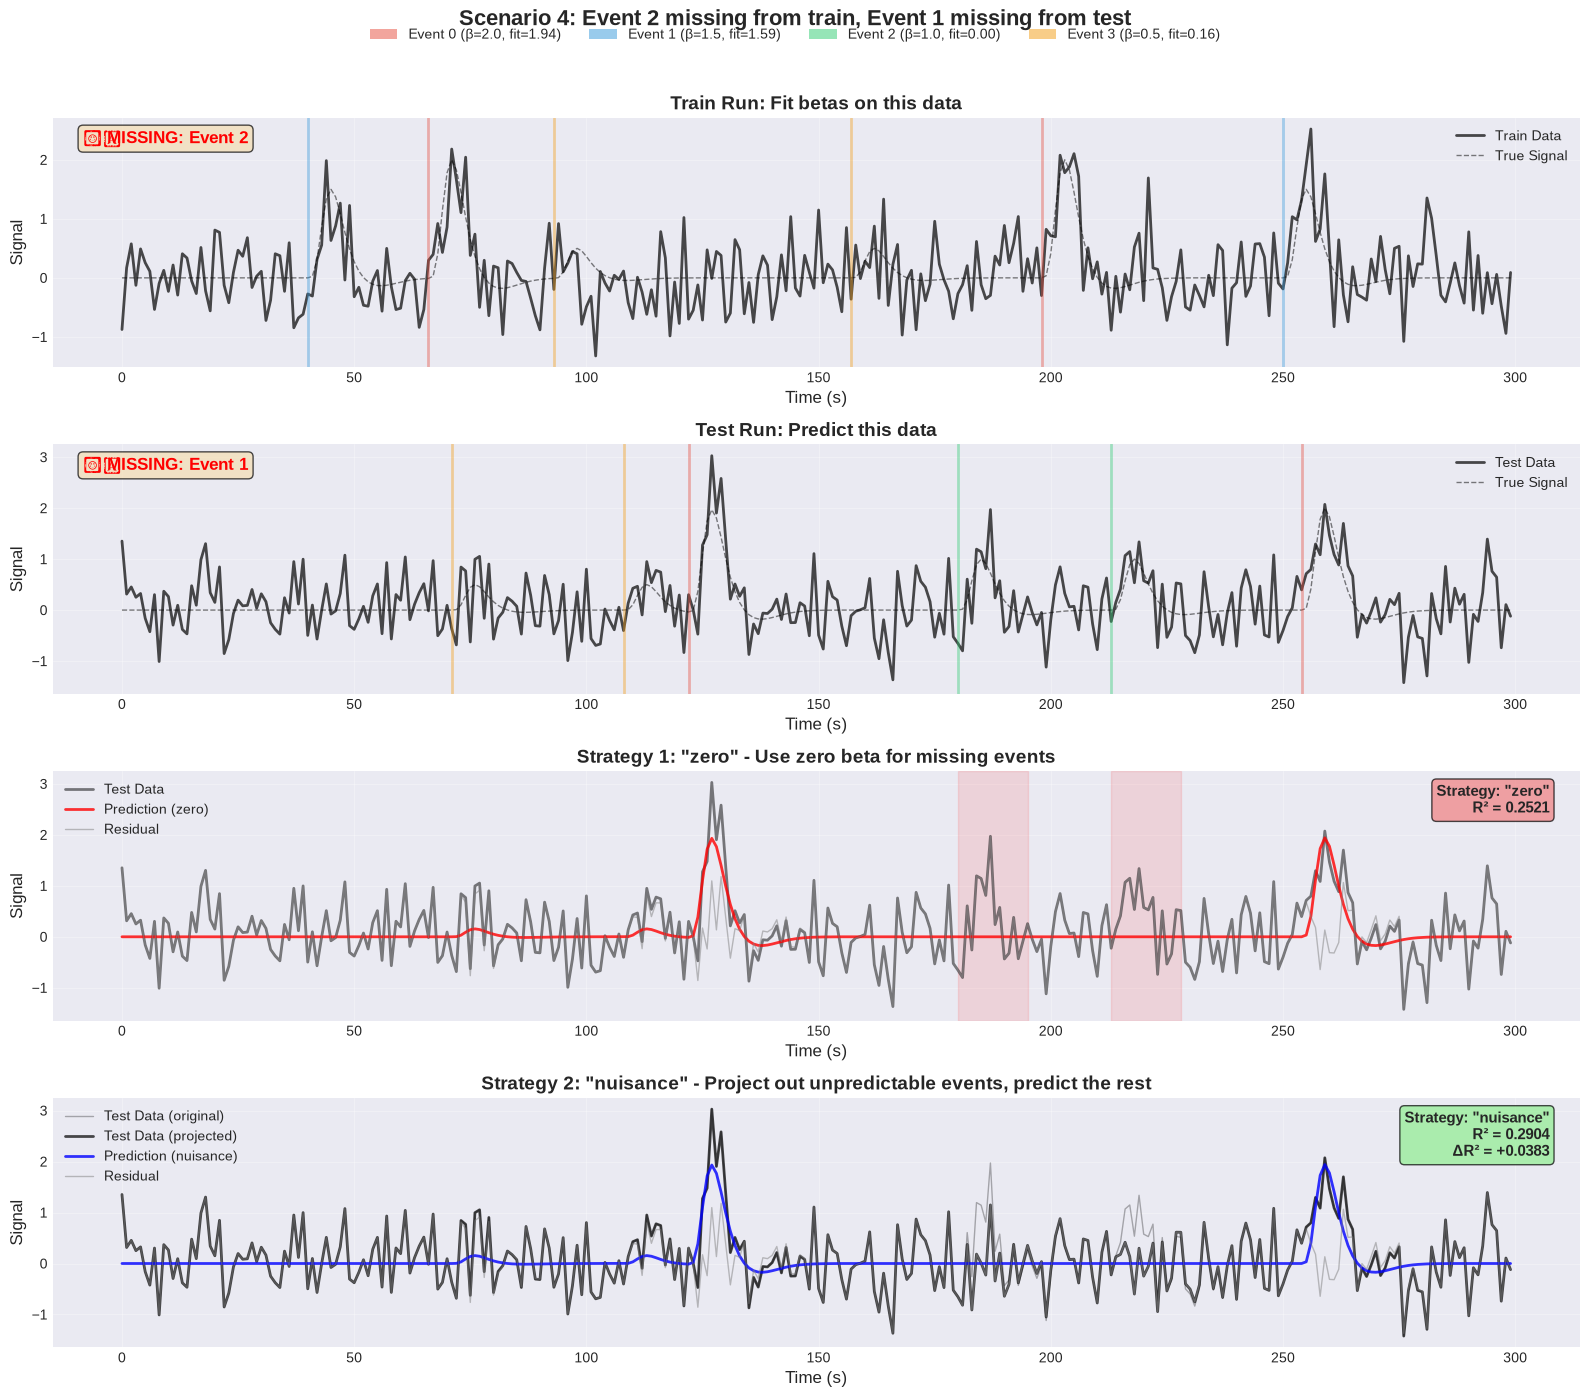

In [20]:
print("\n" + "="*70)
print("SCENARIO 4: Both missing different events")
print("="*70)

data_dict, res_zero, res_nuisance = run_cv_scenario(
    train_missing=[2],
    test_missing=[1],
    verbose=True,
)

plot_scenario(
    data_dict,
    'Scenario 4: Event 2 missing from train, Event 1 missing from test',
    train_missing=[2],
    test_missing=[1],
)

## Scenario 5: Crowded Events — the axis the others hold fixed

Scenario 2 again (Event 2 missing from train), swept across how much the events
overlap.

**Why this case exists.** Scenarios 1-4 keep the events well separated, so the
stimulus columns are near-orthogonal (|r| < 0.1 between the unpredictable event
and the real ones). Under orthogonality an unpredictable event shares nothing
with a real one, and a strategy cannot mishandle variance that is not shared.
Three real bugs in the `"nuisance"` path lived here undetected until this axis
was varied:

1. The projector was applied to the held-out **data** but not to the **design**
   used to predict it, so whatever a predictable condition shared with an
   unpredictable one was removed from one side only and reappeared in the
   residual as fabricated error.
2. Train-only columns were included in the projector basis, where they are
   identically zero -- which is what forced a ridge-stabilised inverse.
3. `"nuisance"` fitted only the *predictable* columns, dropping train-only
   columns from the training fit and letting their variance bias the betas that
   were kept.

At |r| = 0.95 the first bug alone cost **0.24 of R²** (0.334 against 0.570).
Scenarios 1-4 give byte-identical numbers before and after the fix.

**What the sweep shows.** `"nuisance"` wins while the overlap is moderate, and
loses once the unpredictable event is nearly collinear with the real ones. That
last row is not a bug: at |r| = 0.95 the event genuinely destroys the
information, so removing its subspace removes most of what was scorable. The
honest report is a smaller subspace to be scored in — which is the cost this
strategy trades for not inventing error.


SCENARIO 5: Crowded events (Event 2 missing from train)
                     spacing   max|r|     zero   nuisance     delta
 well separated (Scenario 2)    0.077   0.3372     0.3828   +0.0456
                 overlapping    0.289   0.4523     0.4905   +0.0382
            nearly collinear    0.947   0.6565     0.5698   -0.0868
Train missing: [2]
Test missing:  []
True betas:    [2.  1.5 1.  0.5]
Fitted betas:  [1.62103538 1.57409168 0.         0.39884893]

R² (zero):     0.4523
R² (nuisance): 0.4905
Improvement:   0.0382


/tmp/ipykernel_2306656/89214026.py:125: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


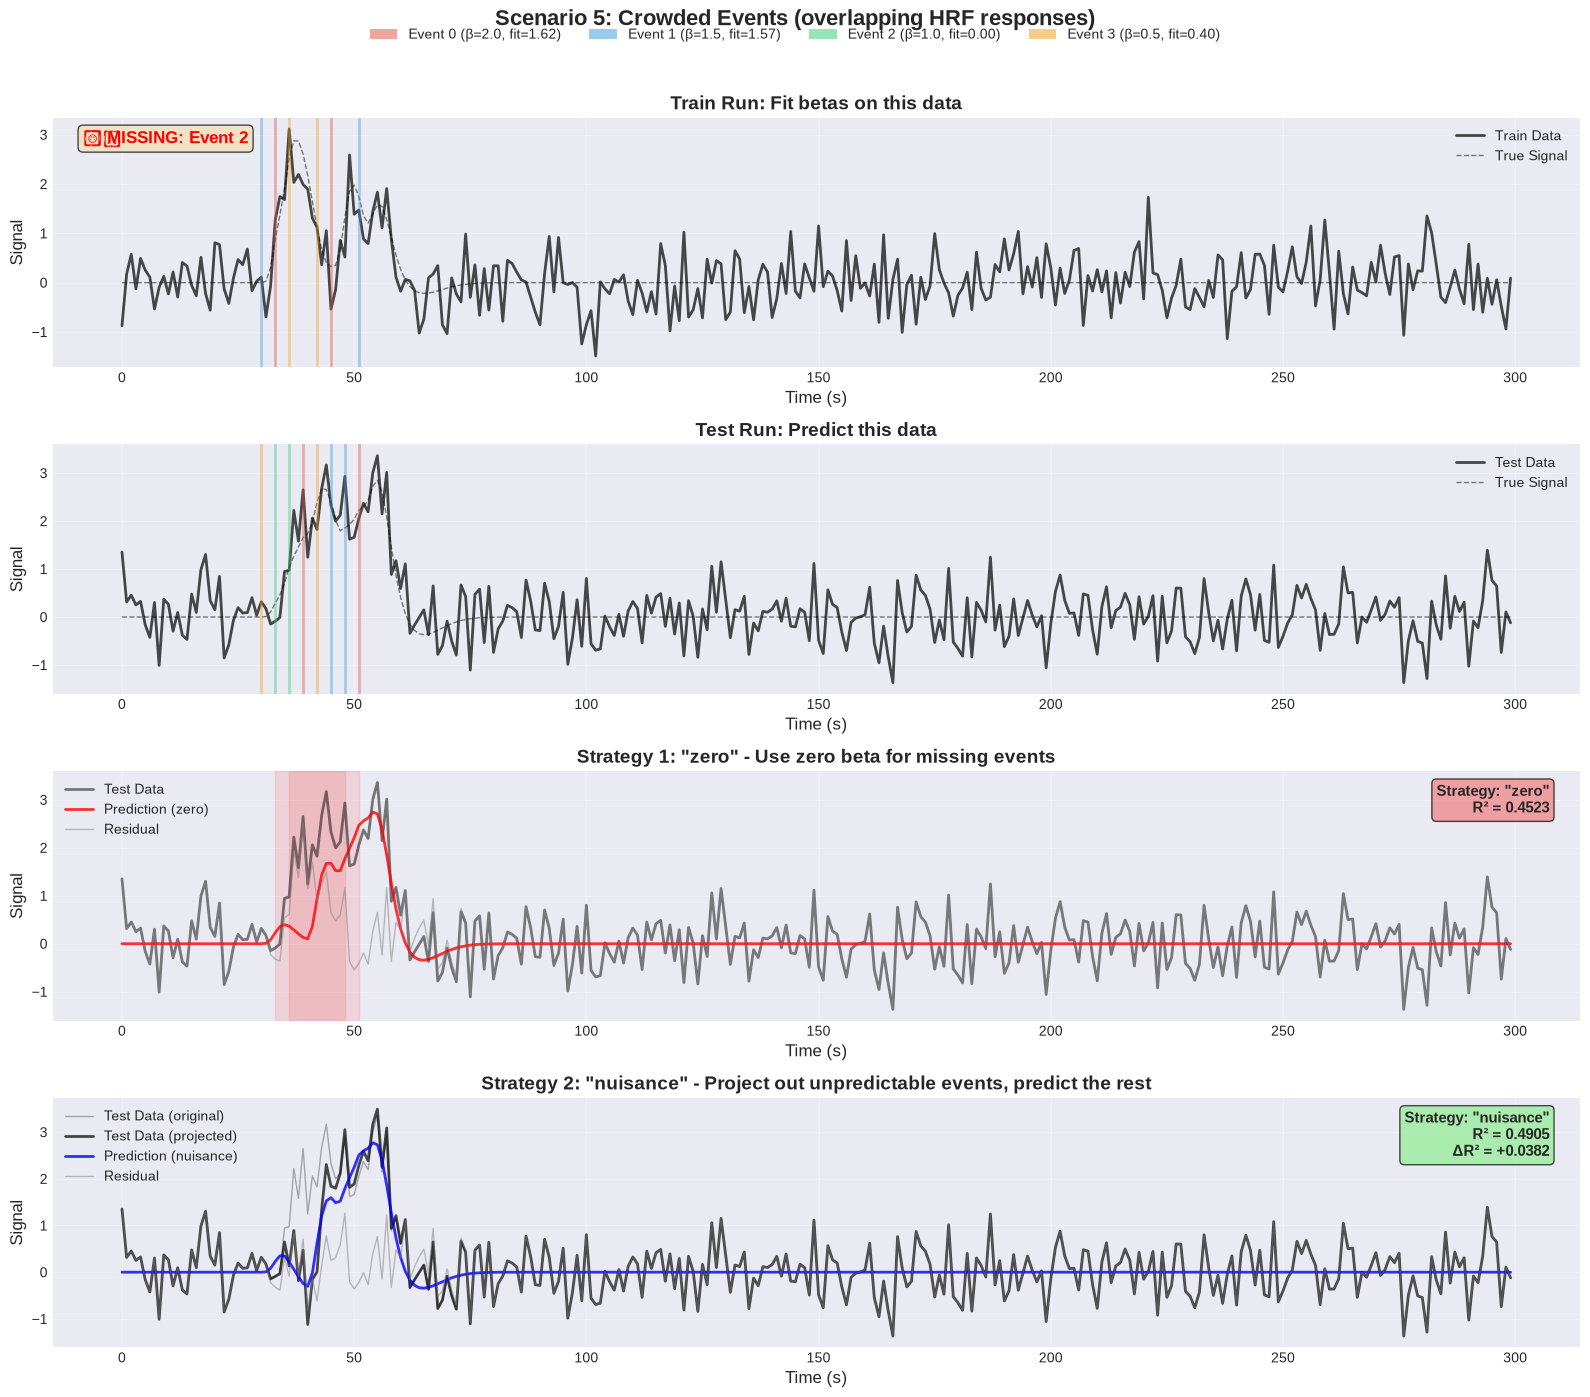

In [21]:
print("\n" + "="*70)
print("SCENARIO 5: Crowded events (Event 2 missing from train)")
print("="*70)
print(f"{'spacing':>28s}  {'max|r|':>7s}  {'zero':>7s}  {'nuisance':>9s}  {'delta':>8s}")

# Same missing-event structure as Scenario 2; only the spacing changes.
for label, crowd in [("well separated (Scenario 2)", 1.0),
                     ("overlapping", 0.12),
                     ("nearly collinear", 0.06)]:
    d, _, _ = run_cv_scenario(train_missing=[2], test_missing=[], verbose=False, crowd=crowd)
    dt = d["design_test"]
    max_r = max(abs(np.corrcoef(dt[:, 2], dt[:, j])[0, 1]) for j in (0, 1, 3))
    print(f"{label:>28s}  {max_r:7.3f}  {d['r2_zero']:7.4f}  "
          f"{d['r2_nuisance']:9.4f}  {d['r2_nuisance'] - d['r2_zero']:+8.4f}")

d_crowded, _, _ = run_cv_scenario(train_missing=[2], test_missing=[], verbose=True, crowd=0.12)

plot_scenario(
    d_crowded,
    'Scenario 5: Crowded Events (overlapping HRF responses)',
    train_missing=[2],
    test_missing=[],
)

## Summary Comparison

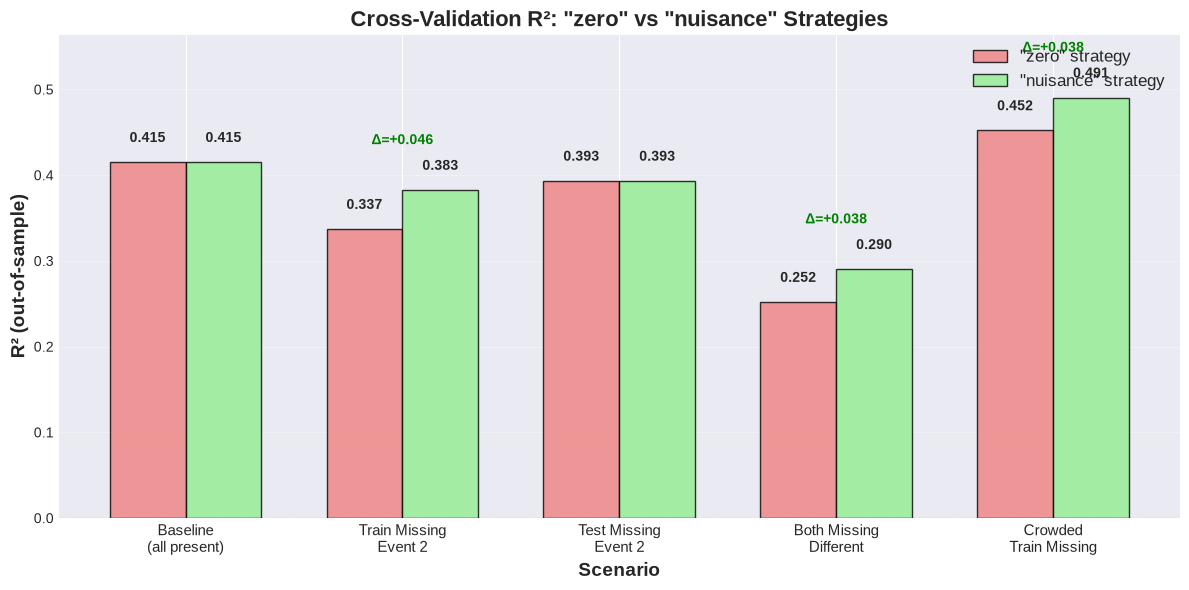


SUMMARY: R² Comparison Across Strategies
Baseline (all present)         zero=0.4153  nuisance=0.4153  Δ=+0.0000
Train Missing Event 2          zero=0.3372  nuisance=0.3828  Δ=+0.0456
Test Missing Event 2           zero=0.3935  nuisance=0.3935  Δ=+0.0000
Both Missing Different         zero=0.2521  nuisance=0.2904  Δ=+0.0383
Crowded Train Missing          zero=0.4523  nuisance=0.4905  Δ=+0.0382

Key Insight:
  - 'nuisance' helps when TRAIN is missing events: the event happens in the
    held-out run with no beta learned for it, so 'zero' charges it to the residual
  - Test-missing events cost nothing either way -- that column is zero across
    the held-out run, so it never enters the prediction under either strategy
  - Separation is the hidden variable: near-orthogonal columns share nothing
    for a strategy to mishandle, which is how three real bugs hid here


In [22]:
# Run all scenarios
scenarios = [
    ('Baseline\n(all present)', [], []),
    ('Train Missing\nEvent 2', [2], []),
    ('Test Missing\nEvent 2', [], [2]),
    ('Both Missing\nDifferent', [2], [1]),
    ('Crowded\nTrain Missing', [2], []),
]
# (label, train_missing, test_missing) -- the last one is rerun with crowd<1
crowd_by_scenario = [1.0, 1.0, 1.0, 1.0, 0.12]

r2_zero_all = []
r2_nuisance_all = []

for (name, train_missing, test_missing), crowd in zip(scenarios, crowd_by_scenario, strict=True):
    data_dict, _, _ = run_cv_scenario(train_missing, test_missing, verbose=False, crowd=crowd)
    r2_zero_all.append(data_dict['r2_zero'])
    r2_nuisance_all.append(data_dict['r2_nuisance'])

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(scenarios))
width = 0.35

bars1 = ax.bar(x - width/2, r2_zero_all, width, label='"zero" strategy', 
               color='lightcoral', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, r2_nuisance_all, width, label='"nuisance" strategy', 
               color='lightgreen', alpha=0.8, edgecolor='black')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add improvement annotations
for i, (r2_z, r2_n) in enumerate(zip(r2_zero_all, r2_nuisance_all, strict=False)):
    improvement = r2_n - r2_z
    if abs(improvement) > 0.005:
        y_pos = max(r2_z, r2_n) + 0.05
        color = 'green' if improvement > 0 else 'red'
        ax.text(i, y_pos, f'Δ={improvement:+.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=color)

ax.set_xlabel('Scenario', fontsize=14, fontweight='bold')
ax.set_ylabel('R² (out-of-sample)', fontsize=14, fontweight='bold')
ax.set_title('Cross-Validation R²: "zero" vs "nuisance" Strategies', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([s[0] for s in scenarios], fontsize=11)
ax.set_ylim([0, max(max(r2_zero_all), max(r2_nuisance_all)) * 1.15])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("SUMMARY: R² Comparison Across Strategies")
print("="*70)
for (name, _, _), r2_z, r2_n in zip(scenarios, r2_zero_all, r2_nuisance_all, strict=False):
    improvement = r2_n - r2_z
    print(f"{name.replace(chr(10), ' '):30s} zero={r2_z:.4f}  nuisance={r2_n:.4f}  Δ={improvement:+.4f}")

print("\nKey Insight:")
print("  - 'nuisance' helps when TRAIN is missing events: the event happens in the")
print("    held-out run with no beta learned for it, so 'zero' charges it to the residual")
print("  - Test-missing events cost nothing either way -- that column is zero across")
print("    the held-out run, so it never enters the prediction under either strategy")
print("  - Separation is the hidden variable: near-orthogonal columns share nothing")
print("    for a strategy to mishandle, which is how three real bugs hid here")